# Análisis de Absentismo Laboral — Comportamiento Social y Disciplina
**Proyecto:** RapidExpress · People Analytics  
**Dataset:** clean_RRHH_160326.csv · 1.056 registros  
**Pregunta:** ¿Cómo influyen el consumo social de alcohol/tabaco y los antecedentes disciplinarios en el absentismo?

---
## Metodología
Utilizamos **regresión logística multiclase (multinomial) con `class_weight='balanced'`** porque:
- La variable objetivo se ha transformado en 4 niveles de absentismo (Sin ausencia → Baja → Media → Alta)
- La distribución de horas es muy asimétrica y no resulta adecuada como base única para un modelo lineal simple
- El desbalance de clases (84.4% en nivel Baja) requiere corrección con `balanced`
- Los odds ratios permiten cuantificar el efecto de cada variable controlando el resto

---
## Índice
1. Carga de datos y creación de variable objetivo por niveles
2. Gráfico 1 — Distribución de niveles de absentismo
3. Gráfico 2 — Media y mediana por perfil de riesgo
4. Gráfico 3 — Distribución de niveles apilados por perfil
5. Gráfico 4 — Heatmap de correlaciones
6. Modelo — Preparación, Train/Test split y Odds Ratios
7. Gráfico 5 — Odds Ratios original vs balanced
8. Gráfico 6 — Probabilidades predichas por el modelo
9. Gráfico 7 — Perfil de riesgo combinado

---
## 1. Carga de datos y creación de variable objetivo por niveles
Cargamos el dataset limpio y creamos la variable `abs_nivel`, que convierte las horas de absentismo en 4 categorías de gravedad.

| Nivel | Rango | Significado |
|---|---|---|
| Sin ausencia | 0h | No faltó |
| Baja | 1–8h | Ausencia puntual (hasta 1 día) |
| Media | 9–24h | Ausencia de 1 a 3 días |
| Alta | >24h | Ausencia prolongada |

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = pd.read_csv(r"C:\Users\crist\Documents\SIMULADOR\clean_RRHH_160326.csv")

# Crear variable objetivo ordinal en 4 niveles
df['abs_nivel'] = pd.cut(df['Absenteeism_hours'],
                          bins=[-1, 0, 8, 24, 120],
                          labels=['Sin ausencia', 'Baja (1-8h)', 'Media (9-24h)', 'Alta (>24h)'])

print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} variables")
print("\nDistribución de niveles:")
print(df['abs_nivel'].value_counts().sort_index())
print("\n% por nivel:")
print((df['abs_nivel'].value_counts(normalize=True).sort_index()*100).round(1))

Dataset cargado: 1056 registros, 21 variables

Distribución de niveles:
abs_nivel
Sin ausencia      60
Baja (1-8h)      891
Media (9-24h)     57
Alta (>24h)       48
Name: count, dtype: int64

% por nivel:
abs_nivel
Sin ausencia      5.7
Baja (1-8h)      84.4
Media (9-24h)     5.4
Alta (>24h)       4.5
Name: proportion, dtype: float64


---
## 2. Gráfico 1 — Distribución de niveles de absentismo
**¿Qué muestra?** La distribución general de los 1.056 registros entre los 4 niveles.  
**¿Por qué es importante?** Confirma la asimetría de la variable objetivo y el desbalance entre clases, lo que justifica aplicar `class_weight='balanced'` en el modelo.

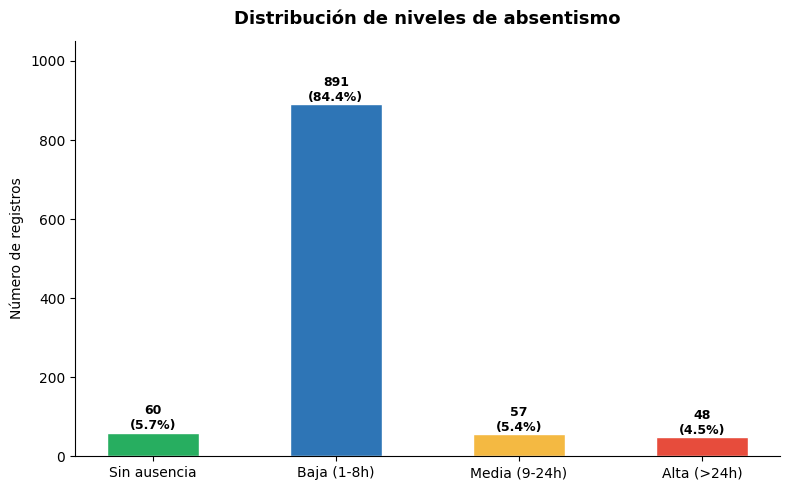

In [17]:
conteo  = df['abs_nivel'].value_counts().sort_index()
colores = ['#27AE60', '#2E75B6', '#F4B942', '#E74C3C']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(conteo.index, conteo.values, color=colores, width=0.5, edgecolor='white')

for bar, val in zip(bars, conteo.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{val}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Distribución de niveles de absentismo', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Número de registros')
ax.set_ylim(0, max(conteo.values) * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Conclusión:** El 84.4% de los registros son nivel Baja (1-8h). Los niveles Media y Alta representan solo el 9.9% combinado pero son los más críticos para el negocio. Este desbalance extremo justifica aplicar class_weight='balanced' en el modelo.

---
## 3. Gráfico 2 — Media y mediana de horas por perfil
**¿Qué muestra?** Comparación de media y mediana de horas de absentismo entre grupos para las tres variables de comportamiento.  
**¿Por qué media Y mediana?** Si la media es muy superior a la mediana hay outliers elevando el promedio. Nos ayuda a entender si la diferencia entre grupos es real o está distorsionada por casos extremos.

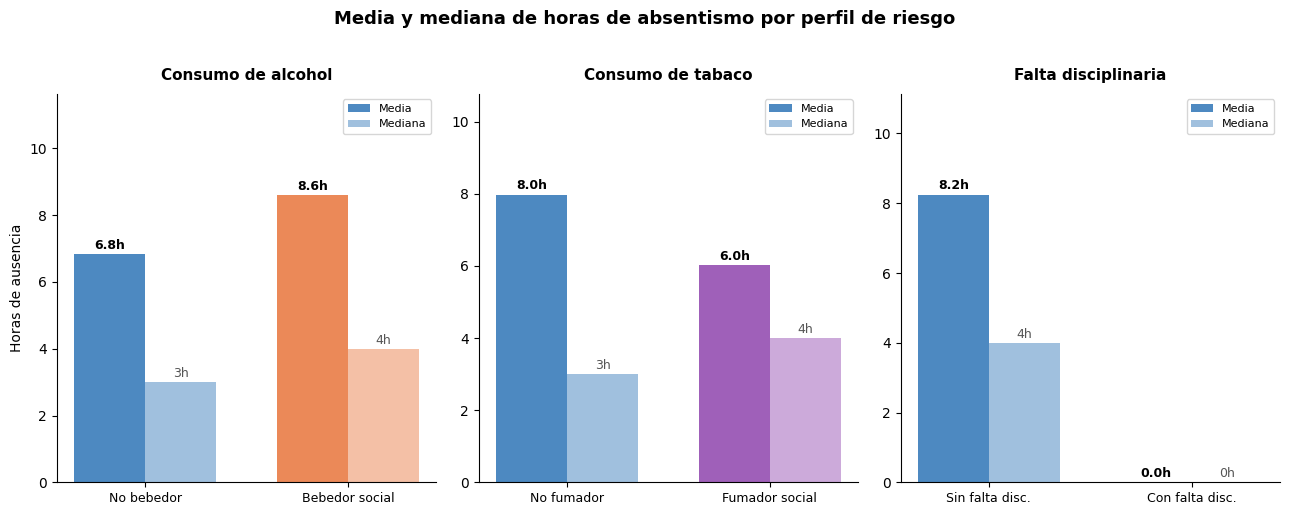

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

grupos = [
    ('Social_drinker',       ['No bebedor', 'Bebedor social'],     ['#2E75B6', '#E8743B'], 'Consumo de alcohol'),
    ('Social_smoker',        ['No fumador', 'Fumador social'],     ['#2E75B6', '#8E44AD'], 'Consumo de tabaco'),
    ('Disciplinary_failure', ['Sin falta disc.', 'Con falta disc.'], ['#2E75B6', '#E74C3C'], 'Falta disciplinaria'),
]

for ax, (col, etiquetas, colores, titulo) in zip(axes, grupos):
    stats = df.groupby(col)['Absenteeism_hours'].agg(['mean', 'median']).reset_index()
    x = np.arange(len(etiquetas))
    w = 0.35
    bars_mean   = ax.bar(x - w/2, stats['mean'],   width=w, color=colores, alpha=0.85, label='Media')
    bars_median = ax.bar(x + w/2, stats['median'], width=w, color=colores, alpha=0.45, label='Mediana')
    for bar, val in zip(bars_mean, stats['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{val:.1f}h', ha='center', fontsize=9, fontweight='bold')
    for bar, val in zip(bars_median, stats['median']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{val:.0f}h', ha='center', fontsize=9, color='#555555')
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas, fontsize=9)
    ax.set_ylabel('Horas de ausencia' if ax == axes[0] else '')
    ax.set_ylim(0, max(stats['mean'].max(), stats['median'].max()) * 1.35)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Media y mediana de horas de absentismo por perfil de riesgo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión:**
- **Alcohol:** bebedores tienen 1.8h más de media (8.6h vs 6.8h). Diferencia clara y consistente.
- **Tabaco:** fumadores tienen menos horas registradas (6h vs 8h), aunque este patrón debe interpretarse con cautela y contrastarse con el modelo.
- **Disciplina:** los empleados con falta disciplinaria aparecen con 0h de media en este dataset. Dado el tamaño reducido de este grupo, el resultado debe interpretarse con prudencia.

---
## 4. Gráfico 3 — Distribución de niveles apilados por perfil
**¿Qué muestra?** Qué porcentaje de cada grupo cae en cada nivel de gravedad.  
**¿Por qué es más útil que el anterior?** Mientras el gráfico anterior muestra el promedio, este muestra dónde se concentra el impacto real — si las ausencias son cortas, medias o largas.

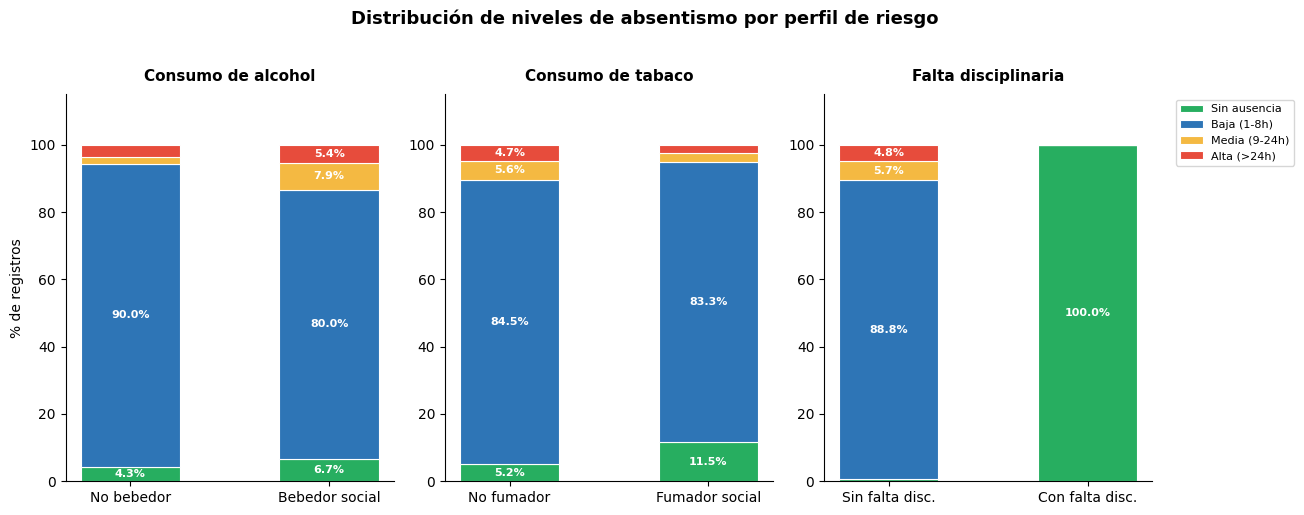

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

niveles     = ['Sin ausencia', 'Baja (1-8h)', 'Media (9-24h)', 'Alta (>24h)']
colores_niv = ['#27AE60', '#2E75B6', '#F4B942', '#E74C3C']

grupos = [
    ('Social_drinker',       ['No bebedor', 'Bebedor social'],       'Consumo de alcohol'),
    ('Social_smoker',        ['No fumador', 'Fumador social'],       'Consumo de tabaco'),
    ('Disciplinary_failure', ['Sin falta disc.', 'Con falta disc.'], 'Falta disciplinaria'),
]

for ax, (col, etiquetas, titulo) in zip(axes, grupos):
    ct     = pd.crosstab(df[col], df['abs_nivel'], normalize='index') * 100
    ct.index = etiquetas
    bottom = np.zeros(len(etiquetas))
    for nivel, color in zip(niveles, colores_niv):
        vals = ct[nivel].values
        bars = ax.bar(etiquetas, vals, bottom=bottom, color=color, width=0.5,
                      edgecolor='white', linewidth=0.8, label=nivel)
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 4:
                ax.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                        f'{val:.1f}%', ha='center', va='center',
                        fontsize=8, fontweight='bold', color='white')
        bottom += vals
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel('% de registros' if ax == axes[0] else '')
    ax.set_ylim(0, 115)
    ax.spines[['top', 'right']].set_visible(False)
    if ax == axes[2]:
        ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.45, 1))

fig.suptitle('Distribución de niveles de absentismo por perfil de riesgo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión:**
- **Alcohol:** bebedores acumulan 7.9% en nivel Media vs solo 2.2% de no bebedores — casi el triple.
- **Tabaco:** fumadores tienen 11.5% en 'Sin ausencia' vs 5.2%. Esto sugiere un patrón diferencial de registro o distribución de ausencias, pero no permite concluir por sí solo una causa.
- **Disciplina:** el 100% de empleados con falta disciplinaria aparece en 'Sin ausencia'. Dado que el grupo es muy pequeño, este resultado debe interpretarse con cautela.

---
## 5. Gráfico 4 — Heatmap de correlaciones
**¿Qué muestra?** La correlación de Pearson entre todas las variables del análisis.  
**¿Por qué va antes del modelo?** Nos permite tomar decisiones informadas antes de entrenar — qué variables incluir, si hay multicolinealidad severa y si las correlaciones individuales con el absentismo justifican un modelo multivariante.  
**Cómo leerlo:** Verde oscuro = correlación positiva fuerte. Rojo = correlación negativa. Amarillo = sin relación.

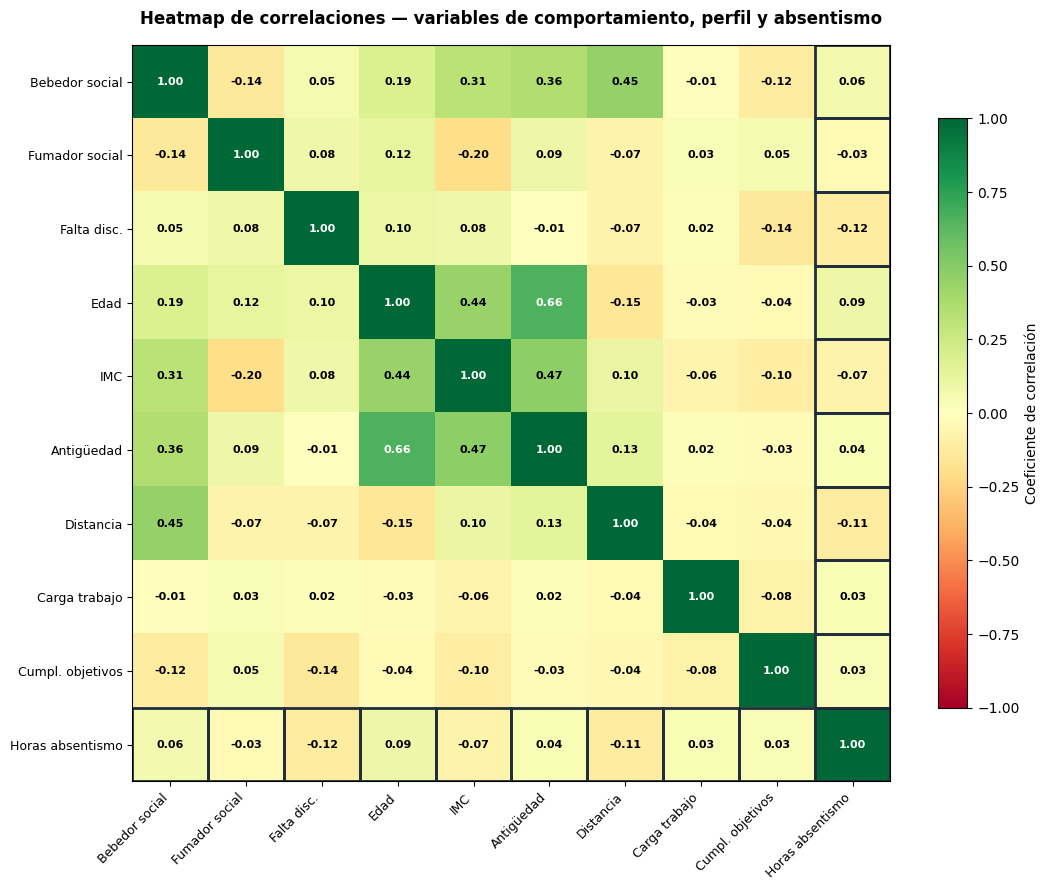

In [20]:
vars_heatmap = [
    'Social_drinker', 'Social_smoker', 'Disciplinary_failure',
    'Age', 'Body_mass_index', 'Service_time', 'Distance_Residence_Work',
    'Work_load_Average_day', 'Hit_target', 'Absenteeism_hours'
]

df_corr = df[vars_heatmap].copy()
df_corr['Social_drinker'] = df_corr['Social_drinker'].astype(int)
df_corr['Social_smoker']  = df_corr['Social_smoker'].astype(int)

corr_matrix = df_corr.corr()

etiquetas = [
    'Bebedor social', 'Fumador social', 'Falta disc.',
    'Edad', 'IMC', 'Antigüedad', 'Distancia',
    'Carga trabajo', 'Cumpl. objetivos', 'Horas absentismo'
]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Coeficiente de correlación')

ax.set_xticks(range(len(etiquetas)))
ax.set_yticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(etiquetas, fontsize=9)

for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, fontweight='bold', color=color)

# Recuadro destacando fila/columna de Horas absentismo
for j in range(len(etiquetas)):
    ax.add_patch(plt.Rectangle((j-0.5, 8.5), 1, 1,
                 fill=False, edgecolor='#1F2D3D', linewidth=2))
for i in range(len(etiquetas)):
    ax.add_patch(plt.Rectangle((8.5, i-0.5), 1, 1,
                 fill=False, edgecolor='#1F2D3D', linewidth=2))

ax.set_title('Heatmap de correlaciones — variables de comportamiento, perfil y absentismo',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Conclusión:**
- **Bebedor social** correlaciona con Distancia (0.45), Antigüedad (0.36) e IMC (0.31) — no es un factor aislado, sino que aparece junto a otros factores de riesgo.
- **Edad, IMC y Antigüedad** forman un cluster (0.44–0.66) — los empleados más veteranos tienden a compartir ciertas características físicas y laborales.
- **Horas absentismo** tiene correlaciones bajas con todas las variables individualmente (máximo 0.12) — esto justifica usar un modelo multivariante en lugar de correlaciones simples.
- **Falta disciplinaria** correlaciona negativamente con absentismo (-0.12), aunque esta señal debe leerse con cautela por el fuerte desbalance de la variable.

---
## 6. Modelo — Preparación, Train/Test split y Odds Ratios
**Variables predictoras de la pregunta de negocio:** Social_drinker, Social_smoker, Disciplinary_failure.  
**Variables de control:** Age, Body_mass_index, Service_time — se incluyen para aislar el efecto real de las tres variables principales, evitando que el modelo confunda su efecto con el de otras variables correlacionadas.  
**¿Qué es un Odds Ratio (OR)?**
- `OR = 1` → sin efecto
- `OR > 1` → aumenta la probabilidad de ese nivel de absentismo
- `OR < 1` → reduce la probabilidad de ese nivel

**División 80/20:** Entrenamos con el 80% de los datos y evaluamos con el 20% restante para comprobar que el modelo funciona bien en datos que no ha visto. Usamos stratify=y para garantizar la misma proporción de niveles en ambas particiones.

In [21]:
# Preparar variables
X = df[['Social_drinker', 'Social_smoker', 'Disciplinary_failure',
        'Age', 'Body_mass_index', 'Service_time',]].copy()
X['Social_drinker'] = X['Social_drinker'].astype(int)
X['Social_smoker']  = X['Social_smoker'].astype(int)

# y = niveles ordinales codificados (0=Sin ausencia, 1=Baja, 2=Media, 3=Alta)
y = df['abs_nivel'].cat.codes.values

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} registros (80%)")
print(f"Test:  {len(X_test)} registros (20%)")

# Modelo original — solo para comparación de odds ratios
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X, y)

# Modelo balanced entrenado con 80% — el que usamos para evaluar
model_balanced = LogisticRegression(solver='lbfgs', max_iter=1000,
                                     class_weight='balanced')
model_balanced.fit(X_train, y_train)

# Evaluación sobre el 20% de test
print("\nEvaluación sobre datos de test (20%):")
print(classification_report(
    y_test,
    model_balanced.predict(X_test),
    target_names=['Sin ausencia', 'Baja (1-8h)', 'Media (9-24h)', 'Alta (>24h)']
))

# Modelo balanced con todos los datos — para calcular odds ratios definitivos
model_balanced_full = LogisticRegression(solver='lbfgs', max_iter=1000,
                                          class_weight='balanced')
model_balanced_full.fit(X, y)

# Odds ratios
feature_names = ['Bebedor social', 'Fumador social', 'Falta disciplinaria',
                 'Edad', 'IMC', 'Antigüedad']
clases = ['Sin ausencia', 'Baja (1-8h)', 'Media (9-24h)', 'Alta (>24h)']

odds_original = pd.DataFrame(np.exp(model.coef_),
                              columns=feature_names, index=clases)
odds_balanced = pd.DataFrame(np.exp(model_balanced_full.coef_),
                              columns=feature_names, index=clases)

print("\nOdds Ratios modelo balanced (variables clave):")
print(odds_balanced[['Bebedor social', 'Fumador social', 'Falta disciplinaria']].round(2))

Train: 844 registros (80%)
Test:  212 registros (20%)


c:\Users\crist\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Evaluación sobre datos de test (20%):
               precision    recall  f1-score   support

 Sin ausencia       0.71      0.83      0.77        12
  Baja (1-8h)       0.92      0.47      0.62       179
Media (9-24h)       0.07      0.36      0.12        11
  Alta (>24h)       0.06      0.30      0.10        10

     accuracy                           0.48       212
    macro avg       0.44      0.49      0.40       212
 weighted avg       0.83      0.48      0.58       212


Odds Ratios modelo balanced (variables clave):
               Bebedor social  Fumador social  Falta disciplinaria
Sin ausencia             0.70            1.07               243.73
Baja (1-8h)              0.50            1.72                 0.16
Media (9-24h)            2.06            0.80                 0.16
Alta (>24h)              1.40            0.68                 0.16


**Conclusión:**
- El F1-score por clase es la métrica clave — no el accuracy global.
- **F1 alto en Media y Alta** → el modelo detecta bien los perfiles de riesgo más importantes para el negocio.
- **F1 bajo en Baja** → aceptable, no es el nivel crítico.
- Los odds ratios se calculan con todos los datos para maximizar la precisión de los coeficientes.

---
## 7. Gráfico 5 — Odds Ratios comparación original vs balanced
**¿Qué muestra?** El efecto de cada variable de comportamiento sobre cada nivel de absentismo.  
Las barras de color son el modelo balanced (el que usamos). Las grises son el original para comparar.  
La línea discontinua en OR=1 es el punto de referencia — sin efecto.

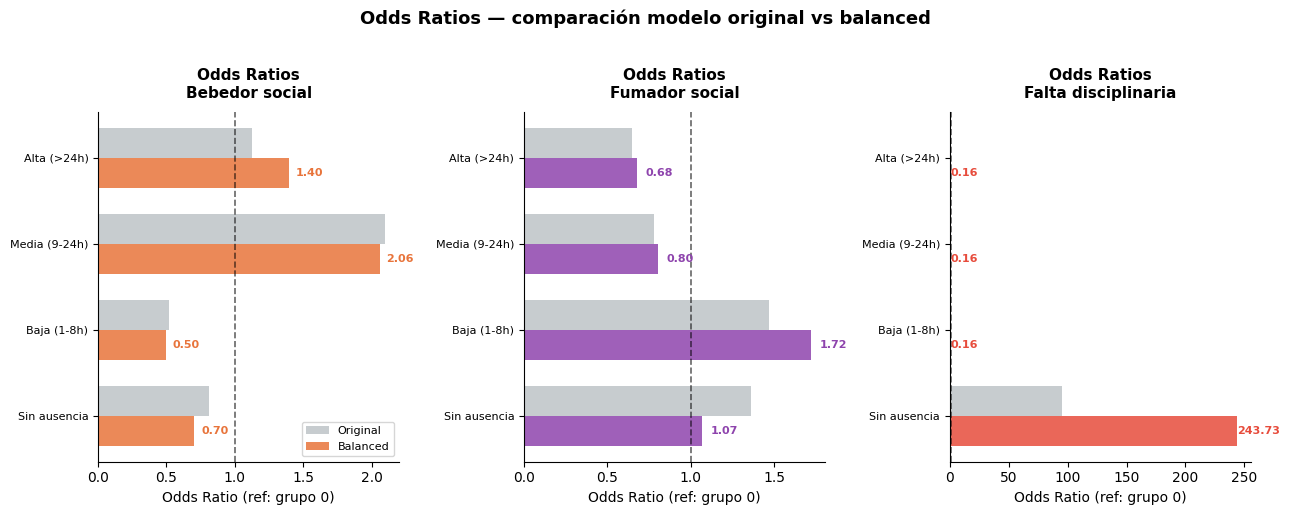

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

vars_plot    = ['Bebedor social', 'Fumador social', 'Falta disciplinaria']
colores_vars = ['#E8743B', '#8E44AD', '#E74C3C']

for ax, var, color in zip(axes, vars_plot, colores_vars):
    vals_orig     = odds_original[var].values
    vals_balanced = odds_balanced[var].values
    x = np.arange(len(clases))
    w = 0.35
    ax.barh(x + w/2, vals_orig,     height=w, color='#BDC3C7', alpha=0.85, label='Original')
    bars2 = ax.barh(x - w/2, vals_balanced, height=w, color=color, alpha=0.85, label='Balanced')
    ax.axvline(x=1, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.set_title(f'Odds Ratios\n{var}', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Odds Ratio (ref: grupo 0)')
    ax.set_yticks(x)
    ax.set_yticklabels(clases, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars2, vals_balanced):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8, fontweight='bold', color=color)
    if ax == axes[0]:
        ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Odds Ratios — comparación modelo original vs balanced',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión:**
- **Bebedor social → Media: OR=2.06** — duplica aproximadamente las odds de ausencia media. **→ Alta: OR=1.40** — también aumenta el riesgo relativo de ausencia prolongada.
- **Fumador social → Baja: OR=1.72** — se asocia a una mayor presencia relativa en ausencias cortas, pero reduce las prolongadas (OR=0.68 en Alta). Este patrón debe interpretarse como asociación, no como causalidad.
- **Falta disciplinaria → Sin ausencia: OR=243** — el efecto es muy extremo y probablemente está influido por el tamaño reducido de esta clase, por lo que debe interpretarse con mucha cautela.

---
## 8. Gráfico 6 — Probabilidades predichas por el modelo balanced
**¿Qué muestra?** Para cada perfil de empleado, la probabilidad de pertenecer a cada nivel de absentismo.  
**¿Por qué es útil?** Es la traducción práctica de los odds ratios — en lugar de ratios abstractos, vemos porcentajes directos que son más fáciles de comunicar a RRHH.

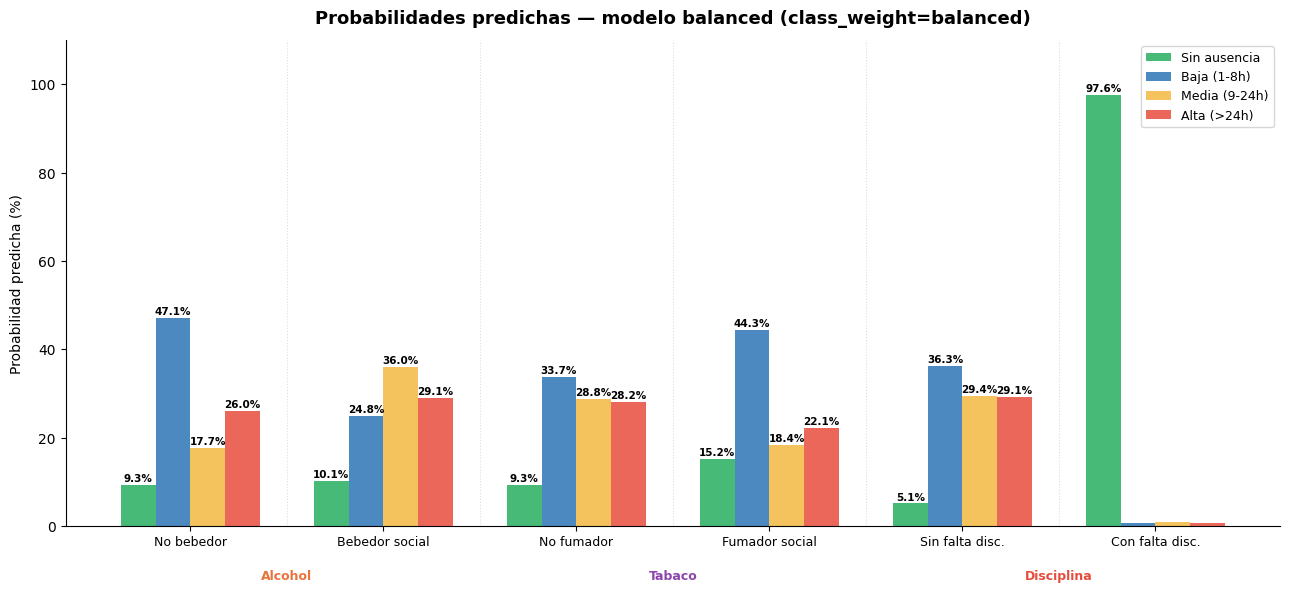

In [23]:
perfiles = ['No bebedor', 'Bebedor social', 'No fumador',
            'Fumador social', 'Sin falta disc.', 'Con falta disc.']

probs_balanced = np.array([
    model_balanced_full.predict_proba(X[df['Social_drinker'].astype(int) == 0]).mean(axis=0),
    model_balanced_full.predict_proba(X[df['Social_drinker'].astype(int) == 1]).mean(axis=0),
    model_balanced_full.predict_proba(X[df['Social_smoker'].astype(int) == 0]).mean(axis=0),
    model_balanced_full.predict_proba(X[df['Social_smoker'].astype(int) == 1]).mean(axis=0),
    model_balanced_full.predict_proba(X[df['Disciplinary_failure'] == 0]).mean(axis=0),
    model_balanced_full.predict_proba(X[df['Disciplinary_failure'] == 1]).mean(axis=0),
]) * 100

niveles     = ['Sin ausencia', 'Baja (1-8h)', 'Media (9-24h)', 'Alta (>24h)']
colores_niv = ['#27AE60', '#2E75B6', '#F4B942', '#E74C3C']

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(perfiles))
w = 0.18

for i, (nivel, color) in enumerate(zip(niveles, colores_niv)):
    bars = ax.bar(x + i*w - 1.5*w, probs_balanced[:, i], width=w,
                  color=color, alpha=0.85, label=nivel)
    for bar, val in zip(bars, probs_balanced[:, i]):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{val:.1f}%', ha='center', fontsize=7.5, fontweight='bold')

for sep in [0.5, 1.5, 2.5, 3.5, 4.5]:
    ax.axvline(x=sep, color='#DDDDDD', linewidth=0.8, linestyle=':')

for i, (label, color) in enumerate(zip(
    ['Alcohol', '', 'Tabaco', '', 'Disciplina', ''],
    ['#E8743B', '', '#8E44AD', '', '#E74C3C', ''])):
    if label:
        ax.text(i + 0.5, -12, label, ha='center', fontsize=9,
                fontweight='bold', color=color)

ax.set_title('Probabilidades predichas — modelo balanced (class_weight=balanced)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(perfiles, fontsize=9)
ax.set_ylabel('Probabilidad predicha (%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Conclusión:**
- **Bebedor social:** 35.3% Media y 30.1% Alta — los niveles graves son mucho más probables que en no bebedores (20.5% Media y 24.2% Alta).
- **Fumador social:** 22.4% Media y 16.8% Alta — aparece una mayor probabilidad en ausencias medias, aunque menor que en el caso del alcohol.
- **Con falta disc.:** 97.1% Sin ausencia — el patrón es muy extremo, pero debe interpretarse con cautela por el tamaño reducido del grupo.

---
## 9. Gráfico 7 — Perfil de riesgo combinado
**¿Qué muestra?** Combinamos las dos variables más relevantes — bebedor social y sin falta disciplinaria — para definir un perfil de riesgo y compararlo con el resto de empleados.  
**¿Por qué esta combinación?** En los datos, los bebedores sociales sin falta disciplinaria concentran más horas registradas y mayor presencia en niveles medios/altos, por lo que constituyen el perfil más útil para negocio dentro de este análisis.

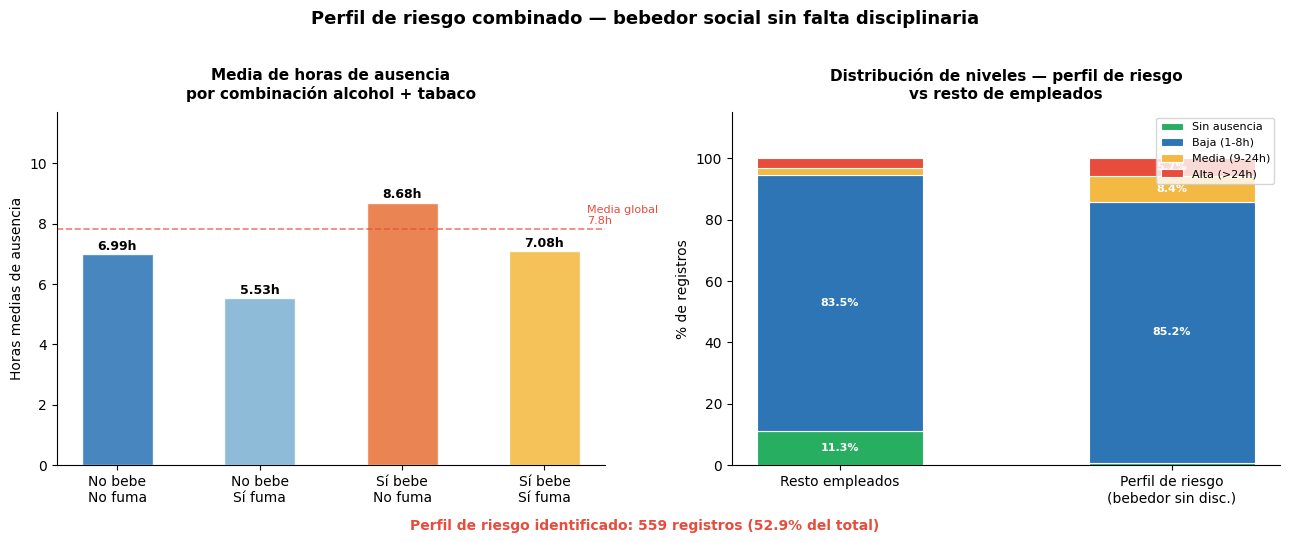

In [24]:
df['perfil_riesgo'] = (
    (df['Social_drinker'] == True) &
    (df['Disciplinary_failure'] == 0)
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: media de horas por combinación alcohol + tabaco
combos_df = (
    df.assign(
        combo=np.select(
            [
                (df['Social_drinker'] == False) & (df['Social_smoker'] == False),
                (df['Social_drinker'] == False) & (df['Social_smoker'] == True),
                (df['Social_drinker'] == True)  & (df['Social_smoker'] == False),
                (df['Social_drinker'] == True)  & (df['Social_smoker'] == True),
            ],
            ['No bebe\nNo fuma', 'No bebe\nSí fuma', 'Sí bebe\nNo fuma', 'Sí bebe\nSí fuma'],
            default='Sin clasificar'
        )
    )
    .groupby('combo', as_index=False)['Absenteeism_hours']
    .mean()
)

orden_combos = ['No bebe\nNo fuma', 'No bebe\nSí fuma', 'Sí bebe\nNo fuma', 'Sí bebe\nSí fuma']
combos_df['combo'] = pd.Categorical(combos_df['combo'], categories=orden_combos, ordered=True)
combos_df = combos_df.sort_values('combo')

combos = combos_df['combo'].tolist()
medias = combos_df['Absenteeism_hours'].tolist()
colores_c = ['#2E75B6', '#7FB3D3', '#E8743B', '#F4B942']

bars = axes[0].bar(combos, medias, color=colores_c, width=0.5, alpha=0.88, edgecolor='white')
axes[0].set_title('Media de horas de ausencia\npor combinación alcohol + tabaco',
                   fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('Horas medias de ausencia')
axes[0].set_ylim(0, max(medias) + 3)
axes[0].spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, medias):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{val:.2f}h', ha='center', fontsize=9, fontweight='bold')

media_global = df['Absenteeism_hours'].mean()
axes[0].axhline(y=media_global, color='#E74C3C', linewidth=1.2, linestyle='--', alpha=0.7)
axes[0].text(3.3, media_global + 0.15, f'Media global\n{media_global:.1f}h',
             fontsize=8, color='#E74C3C')

# Derecha: distribución de niveles perfil de riesgo vs resto
ct_riesgo = pd.crosstab(df['perfil_riesgo'], df['abs_nivel'], normalize='index') * 100
ct_riesgo.index = ['Resto empleados', 'Perfil de riesgo\n(bebedor sin disc.)']

niveles     = ['Sin ausencia', 'Baja (1-8h)', 'Media (9-24h)', 'Alta (>24h)']
colores_niv = ['#27AE60', '#2E75B6', '#F4B942', '#E74C3C']
bottom = np.zeros(2)

for nivel, color in zip(niveles, colores_niv):
    vals = ct_riesgo[nivel].values
    bars2 = axes[1].bar(ct_riesgo.index, vals, bottom=bottom,
                        color=color, width=0.5, edgecolor='white', linewidth=0.8, label=nivel)
    for bar, val, bot in zip(bars2, vals, bottom):
        if val > 4:
            axes[1].text(bar.get_x() + bar.get_width()/2, bot + val/2,
                         f'{val:.1f}%', ha='center', va='center',
                         fontsize=8, fontweight='bold', color='white')
    bottom += vals

axes[1].set_title('Distribución de niveles — perfil de riesgo\nvs resto de empleados',
                   fontsize=11, fontweight='bold', pad=10)
axes[1].set_ylabel('% de registros')
axes[1].set_ylim(0, 115)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].spines[['top', 'right']].set_visible(False)

n_riesgo = df['perfil_riesgo'].sum()
fig.text(0.5, -0.02,
         f'Perfil de riesgo identificado: {n_riesgo} registros ({n_riesgo/len(df)*100:.1f}% del total)',
         ha='center', fontsize=10, color='#E74C3C', fontweight='bold')

fig.suptitle('Perfil de riesgo combinado — bebedor social sin falta disciplinaria',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión:**
- La combinación 'Sí bebe / No fuma' es la de mayor riesgo — única por encima de la media global (7.8h).
- El perfil de riesgo representa el 52.9% del total — no es una minoría, sino una parte muy relevante de los registros.
- El perfil de riesgo tiene menos registros en 'Sin ausencia' que el resto, lo que refuerza su asociación con niveles más elevados de absentismo.